In [1]:
import bz2, pickle
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))
import synmorph as sm

In [13]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

def per_cell_msd(x_save, max_lag=None, subtract_com=False, mask=None):
    """
    Compute MSD for each cell.

    x_save: (T, N, d)
    max_lag: maximum lag (int). If None, uses T//2.
    subtract_com: if True, subtract center-of-mass motion of the selected cells before MSD.
    mask: boolean array of length N OR None. If provided and subtract_com==True, COM is computed over mask.
          If provided and subtract_com==False, mask is ignored (msd still returned for all cells).
    
    Returns:
      lag_times: 1D array length max_lag (indices 0..max_lag-1)
      msd_per_cell: array shape (max_lag, N) with msd_per_cell[0]=0
    """
    T, N, d = x_save.shape
    if max_lag is None:
        max_lag = T // 2
    max_lag = int(max_lag)
    # Optionally subtract COM (computed per time across masked cells)
    x = x_save.copy()
    if subtract_com and mask is not None:
        mask = np.asarray(mask, dtype=bool)
        if mask.sum() == 0:
            raise ValueError("Mask has zero True entries for COM subtraction.")
        com = np.sum(x[:, mask, :], axis=1) / mask.sum()  # shape (T, d)
        # subtract COM from all positions (so positions become relative to COM)
        x = x - com[:, None, :]
    
    msd_per_cell = np.zeros((max_lag, N), dtype=float)
    # tau = 0 -> MSD 0
    for tau in range(1, max_lag):
        disp = x[tau:, :, :] - x[:-tau, :, :]        # shape (T-tau, N, d)
        sqdist = np.sum(disp**2, axis=2)            # shape (T-tau, N)
        msd_per_cell[tau, :] = np.mean(sqdist, axis=0)  # average over time for each cell
    lag_times = np.arange(max_lag)
    return lag_times, msd_per_cell


def msd_by_mask(msd_per_cell, mask):
    """
    Average per-cell MSD across cells selected by mask.

    msd_per_cell: (max_lag, N)
    mask: boolean length N
    returns: msd_masked (max_lag,)
    """
    mask = np.asarray(mask, dtype=bool)
    if mask.sum() == 0:
        raise ValueError("Empty mask passed to msd_by_mask.")
    return np.mean(msd_per_cell[:, mask], axis=1)


def fit_diffusion_from_msd(lag_times, msd, dt=1.0, dim=2, fit_range=None):
    """
    Fit linear MSD = slope * t + intercept, return D_eff = slope/(2*dim).
    lag_times: array of lag indices (0..)
    msd: array of same length
    dt: time step per index
    fit_range: slice-like or tuple(start, stop) for indices. If None uses (1, len(lag_times)//2)
    
    Returns: dict with keys: D_eff, slope, intercept, r_value, p_value, stderr, t_fit, msd_fit
    """
    if fit_range is None:
        start = 1
        stop = len(lag_times)//2
    else:
        start, stop = fit_range
    start = int(start); stop = int(stop)
    t = lag_times * dt
    x = t[start:stop]
    y = msd[start:stop]
    if len(x) < 2:
        raise ValueError("Fit range too small.")
    slope, intercept, r_value, p_value, stderr = linregress(x, y)
    D_eff = slope / (2.0 * dim)
    # For plotting fitted line
    msd_fit = slope * t + intercept
    return {
        "D_eff": D_eff,
        "slope": slope,
        "intercept": intercept,
        "r_value": r_value,
        "p_value": p_value,
        "stderr": stderr,
        "t_fit": t,
        "msd_fit": msd_fit,
        "fit_indices": (start, stop)
    }


def compute_and_fit_group_D(x_save, LEP=None, MEP=None, lep_value=0, mep_value=1,
                            dt=1.0, dim=2, max_lag=None, subtract_com=False,
                            fit_range=None, verbose=True):
    """
    High-level convenience function:
      - compute per-cell MSD (optionally subtract COM for each mask)
      - compute group-averaged MSD for LEP, MEP and combined tissue
      - fit D_eff for each group using fit_range
    
    LEP, MEP: arrays length N giving type values (e.g., LEP array where real LEP cells have value 0).
    lep_value, mep_value: the value that identifies the 'real' types per user's convention.
    
    Returns:
      results: dict with keys 'lag_times', 'msd_per_cell', and per-group dicts:
               'LEP', 'MEP', 'tissue' each containing msd and fit results.
    """
    T, N, d = x_save.shape
    if max_lag is None:
        max_lag = T // 2

    # assume LEP and MEP are arrays of length N (or None)
    # Create boolean masks for cell membership:
    if LEP is None or MEP is None:
        raise ValueError("You must pass LEP and MEP arrays of length N.")
    LEP = np.asarray(LEP)
    MEP = np.asarray(MEP)
    if LEP.shape[0] != N or MEP.shape[0] != N:
        raise ValueError("LEP/MEP must have length equal to number of cells N.")

    lep_mask = (LEP == lep_value)
    mep_mask = (MEP == mep_value)
    tissue_mask = lep_mask | mep_mask

    # compute per-cell MSD with optional COM subtraction (COM computed using tissue_mask if subtract_com True)
    com_mask = tissue_mask if subtract_com else None
    lag_times, msd_per_cell = per_cell_msd(x_save, max_lag=max_lag, subtract_com=subtract_com, mask=com_mask)

    # group-averaged MSD
    msd_lep = msd_by_mask(msd_per_cell, lep_mask) if lep_mask.sum()>0 else None
    msd_mep = msd_by_mask(msd_per_cell, mep_mask) if mep_mask.sum()>0 else None
    msd_tissue = msd_by_mask(msd_per_cell, tissue_mask) if tissue_mask.sum()>0 else None

    results = {
        "lag_times": lag_times,
        "msd_per_cell": msd_per_cell,
        "masks": {"lep_mask": lep_mask, "mep_mask": mep_mask, "tissue_mask": tissue_mask},
        "groups": {}
    }

    # Fit each group (if present)
    for name, msd in (("LEP", msd_lep), ("MEP", msd_mep), ("tissue", msd_tissue)):
        if msd is None:
            results["groups"][name] = None
            continue
        fit_res = fit_diffusion_from_msd(lag_times, msd, dt=dt, dim=dim, fit_range=fit_range)
        results["groups"][name] = {"msd": msd, "fit": fit_res}

        if verbose:
            print(f"{name}: cells = { (lep_mask if name=='LEP' else mep_mask).sum() if name in ('LEP','MEP') else tissue_mask.sum() } "
                  f" D_eff = {fit_res['D_eff']:.4e}  slope={fit_res['slope']:.4e}  R^2={(fit_res['r_value']**2):.4f}")

    return results


def plot_group_msd(results, dt=1.0, dim=2, show_fit=True):
    """
    Plot group MSDs and fitted lines on log–log axes.
    """
    lag_times = results["lag_times"]
    t = lag_times * dt
    plt.figure(figsize=(6,4))
    colors = {"LEP":"C0", "MEP":"C1", "tissue":"C2"}

    for name in ("LEP","MEP"):
        grp = results["groups"].get(name)
        if grp is None:
            continue
        msd = grp["msd"]

        # raw MSD curve
        plt.loglog(t[1:], msd[1:], marker='o', linestyle='None',
                   label=f"{name} MSD", markersize=3)

        # fitted line
        if show_fit:
            fit = grp["fit"]
            plt.loglog(t, fit["msd_fit"], linestyle='--',
                       label=f"{name} fit, Deff={fit['D_eff']:.2e}")

    plt.xlabel("lag time")
    plt.ylabel("MSD")
    plt.legend()
    plt.title("Group MSDs (log–log) with fits")
    plt.tight_layout()
    plt.show()
    alpha = np.gradient(np.log(msd[1:]), np.log(t[1:]))
    plt.plot(t[1:], alpha)
    plt.xlabel("time")
    plt.ylabel("local scaling exponent α(t)")
    plt.xscale("log")




In [16]:
tau_vals = [0.02, 0.04, 0.08, 0.16] # [0.01, 0.02, 0.04, 0.08, 0.16]
Dr_vals = 1/np.array(tau_vals)
v0_vals = [0.05, 0.1, 0.2, 0.4] # [0.01, 0.05, 0.1, 0.2, 0.4, 0.8]
replicates = range(1,26)
simulation_file_name = f'Dr{round(Dr_vals[3], 3)}_v{v0_vals[3]}_{replicates[0]}'

with bz2.BZ2File("./results/Jamming_Boundary/" + simulation_file_name + "_simulation.pbz2", "rb") as f:
    sim = pickle.load(f)

print(sim.keys())
print(sim["t_span_save"])

dict_keys(['simulation_params', 'save_options', 't', 't_span', 't_span_save', 'nt', 'nts', 'x_save', 'tri_save', 'var_save', 'grn', 'phi_save', 'ejected_save', 'date', 'name', 'id', 'save_dir', 'save_dir_pickled', 'save_dir_plots'])
[0.000e+00 1.000e+00 2.000e+00 ... 7.997e+03 7.998e+03 7.999e+03]


LEP: cells = 26  D_eff = 6.5198e-03  slope=2.6079e-02  R^2=0.9996
MEP: cells = 25  D_eff = 1.2187e-02  slope=4.8748e-02  R^2=0.9992
tissue: cells = 51  D_eff = 9.2978e-03  slope=3.7191e-02  R^2=0.9994


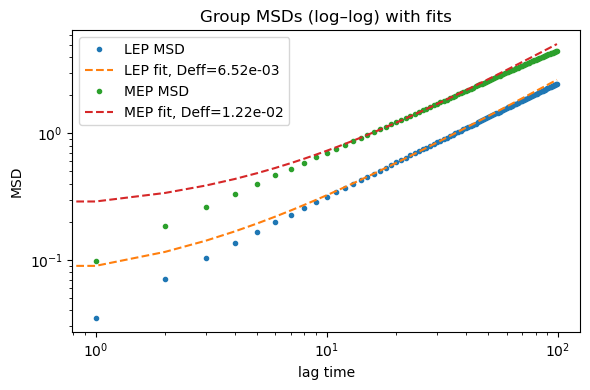

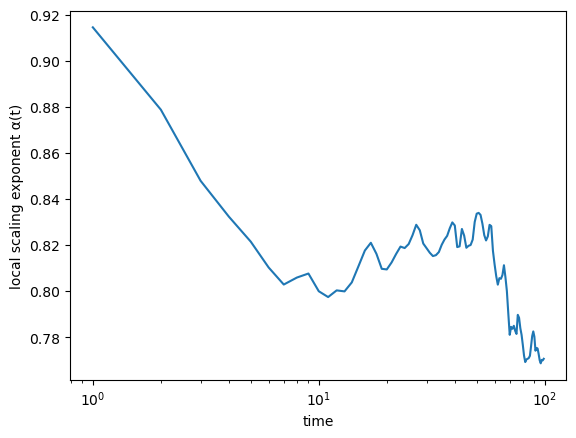

In [17]:
# x_save shape (T, N, d)
# LEP, MEP are arrays of length N, e.g. LEP[i] == 0 for LEP cells, MEP[i] == 1 for MEP cells.
results = compute_and_fit_group_D(
    sim["x_save"],
    LEP=sim["t"].c_types,
    MEP=sim["t"].c_types,
    lep_value=0,
    mep_value=1,
    dt=1,         # set to your simulation time step
    dim=2,          # spatial dimension
    max_lag=100,
    subtract_com=False,   # set True if you want COM drift removed
    fit_range=(10, 40), # choose indices corresponding to linear region
    verbose=True
)
plot_group_msd(results, dt=1, dim=2, show_fit=True)

# Access D_eff:
D_lep = results["groups"]["LEP"]["fit"]["D_eff"]
D_mep = results["groups"]["MEP"]["fit"]["D_eff"]
D_tissue = results["groups"]["tissue"]["fit"]["D_eff"]

phi_b_full shape: (100,)
Original length: 80
Rolling average length: 61


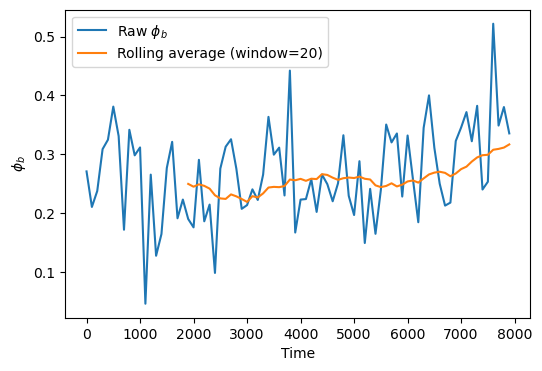

In [ ]:
# Example: phi array from a single simulation
phi_b_full = sim['phi_save'][:,2]  # shape (n_datapoints,)
print("phi_b_full shape:", phi_b_full.shape)

# Parameters
burn = 20
window = 20

# burn first 20 points
phi_b = phi_b_full[burn:]  # shape (80,)

# Compute rolling average
# NumPy version
phi_b_rolling = np.convolve(phi_b, np.ones(window)/window, mode='valid')

print("Original length:", len(phi_b))
print("Rolling average length:", len(phi_b_rolling))

plt.figure(figsize=(6,4))
plt.plot(np.arange(0,8000,100), phi_b, label=r'Raw $\phi_b$')
plt.plot(100*np.array(range(window-1, len(phi_b))), phi_b_rolling, label=f'Rolling average (window={window})')
plt.xlabel('Time')
plt.ylabel(r'$\phi_b$')
plt.legend()
plt.show()

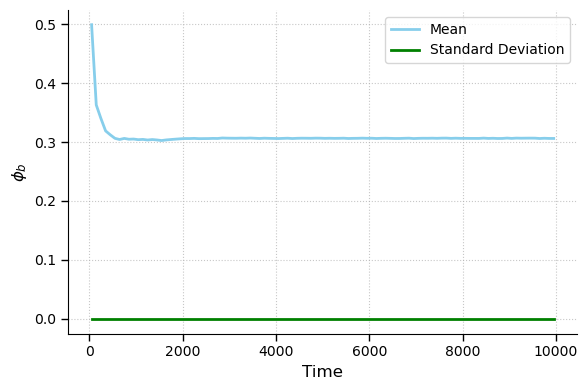

In [34]:
from data_analytics import binned_stats

binned_stats(data, bin_size=100)

In [25]:
print(np.any(data['ejected_save']))

False


In [9]:
path = "./results/Activity_Sweep/Dr50.0_v0.15_1_simulation.pbz2"
print("Exists:", os.path.exists(path))
print("Absolute path:", os.path.abspath(path))

Exists: False
Absolute path: /Users/taylorwomack/Library/CloudStorage/Box-Box/Gartnerlab Data/Rotations/Taylor Womack/synmorph/results/Activity_Sweep/Dr50.0_v0.15_1_simulation.pbz2
